# NB-B · CIF — 154 Classes, 50 Trees, Checkpointed

Trains CanonicalIntervalForest on the 154-class hand-only dataset.
**50 trees, n_jobs=-1, batch checkpointing every 5 trees.**

If Colab crashes: re-run from Cell 2 — resumes from last checkpoint automatically.

Results -> `OBrown_DIS9300_v2/results/cif_154/`


In [1]:
import subprocess, sys
subprocess.check_call([sys.executable,'-m','pip','install',
    'numba==0.62.1','llvmlite==0.45.0','sktime',
    'scikit-learn','joblib','--force-reinstall','-q'])
print('Done. RESTART KERNEL -> Runtime -> Restart session')


Done. RESTART KERNEL -> Runtime -> Restart session


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy, numba
print(f'numba={numba.__version__}')
assert numba.__version__=='0.62.1','Rerun Cell 1 and restart kernel'


numba=0.62.1


In [3]:
import os, json, gzip, shutil, time
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import psutil

PROJECT_DIR = ('/content/drive/MyDrive/Consultant/Colab_Notebooks/'
               'Obrown_Dissertation_NU_25/OBrown_DIS9300_v2')
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results', 'cif_154')
os.makedirs(os.path.join(RESULTS_DIR,'checkpoints'), exist_ok=True)

TRAIN_NPZ    = os.path.join(PROJECT_DIR, 'ASL_154_train_cif.npz')
TEST_NPZ     = os.path.join(PROJECT_DIR, 'ASL_154_test_cif.npz')
LE_PATH      = os.path.join(PROJECT_DIR, 'ASL_154_label_encoder.pkl')

N_ESTIMATORS = 50
BATCH_SIZE   = 5
ATT_SUB      = 7
RANDOM_STATE = 42
MODEL_NAME   = 'CIF 154-class (50 trees)'
MODEL_TAG    = 'cif_154'

ram = psutil.virtual_memory().total/1024**3
print(f'RAM: {ram:.1f}GB')
if ram < 20: print('WARNING: Use High-RAM runtime')
print(f'N_ESTIMATORS : {N_ESTIMATORS}  BATCH: {BATCH_SIZE}  ATT_SUB: {ATT_SUB}')
print(f'Results      -> {RESULTS_DIR}')


RAM: 51.0GB
N_ESTIMATORS : 50  BATCH: 5  ATT_SUB: 7
Results      -> /content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/OBrown_DIS9300_v2/results/cif_154


In [4]:
# Load data
d_tr = np.load(TRAIN_NPZ, allow_pickle=True)
d_te = np.load(TEST_NPZ,  allow_pickle=True)
X_train, y_train = d_tr['X'], d_tr['y']  # y already integer-encoded
X_test,  y_test  = d_te['X'], d_te['y']
le = joblib.load(LE_PATH)
N_CLASSES = len(le.classes_)

# Impute any residual NaN
for nm, X in [('train',X_train),('test',X_test)]:
    if np.isnan(X).sum() > 0:
        col_means = np.nanmean(X, axis=(0,2))
        col_means = np.where(np.isnan(col_means), 0, col_means)
        for c in range(X.shape[1]):
            mask = np.isnan(X[:,c,:])
            if mask.any(): X[:,c,:][mask] = col_means[c]
        print(f'Imputed NaN in {nm}')

print(f'Train: {X_train.shape}  classes={N_CLASSES}')
print(f'Test : {X_test.shape}')
print(f'Input: (n, 126 hand channels, 40 frames) -- raw MediaPipe coords')


Train: (926, 126, 40)  classes=154
Test : (309, 126, 40)
Input: (n, 126 hand channels, 40 frames) -- raw MediaPipe coords


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [5]:
try:
    from sktime.classification.interval_based import CanonicalIntervalForest
    print('sktime imported')
except ModuleNotFoundError:
    raise SystemExit('Restart kernel then re-run from Cell 3')

model_path    = os.path.join(RESULTS_DIR, 'cif_model.pkl')
progress_path = os.path.join(RESULTS_DIR, 'checkpoints', 'progress.pkl')

if os.path.exists(model_path):
    print('[SKIP] Loading saved model...')
    clf = joblib.load(model_path)
else:
    if os.path.exists(progress_path):
        prog = joblib.load(progress_path)
        trees_done = prog['trees_done']
        single_tree_clfs = prog['single_tree_clfs']
        print(f'[RESUME] {trees_done}/{N_ESTIMATORS} trees done')
    else:
        trees_done, single_tree_clfs = 0, []
        print(f'[START] 0/{N_ESTIMATORS} trees')

    print(f'Input: {X_train.shape}  Classes: {N_CLASSES}  n_jobs=-1')

    for bs in range(trees_done, N_ESTIMATORS, BATCH_SIZE):
        be = min(bs + BATCH_SIZE, N_ESTIMATORS)
        t0 = time.time()
        bc = CanonicalIntervalForest(
            n_estimators       = be - bs,
            att_subsample_size = ATT_SUB,
            n_jobs             = -1,         # use all cores
            random_state       = RANDOM_STATE + bs,
        )
        bc.fit(X_train, y_train)
        single_tree_clfs.append(bc)
        trees_done = be
        el = (time.time()-t0)/60
        rm = ((N_ESTIMATORS-trees_done)/BATCH_SIZE)*el
        print(f'  Trees {bs+1}-{be}/{N_ESTIMATORS}  {el:.1f}min  ~{rm:.0f}min left')
        joblib.dump({'trees_done':trees_done,
                     'single_tree_clfs':single_tree_clfs}, progress_path)

    # Merge all single-tree CIFs into one
    print('Merging trees...')
    all_est, all_int, all_dim, all_att = [], [], [], []
    for bc in single_tree_clfs:
        if hasattr(bc,'estimators_') and bc.estimators_:
            all_est.extend(bc.estimators_)
        for attr, lst in [('intervals_',all_int),('dims_',all_dim),('atts_',all_att)]:
            v = getattr(bc, attr, None)
            if v is not None: lst.extend(list(v))
    clf = single_tree_clfs[0]
    clf.estimators_ = all_est
    if all_int: clf.intervals_ = tuple(all_int)
    if all_dim: clf.dims_      = tuple(all_dim)
    if all_att: clf.atts_      = tuple(all_att)
    joblib.dump(clf, model_path)
    with open(model_path,'rb') as fi, gzip.open(model_path+'.gz','wb') as fo:
        shutil.copyfileobj(fi, fo)
    with open(os.path.join(RESULTS_DIR,'cif_154_config.json'),'w') as f:
        json.dump({'n_estimators':N_ESTIMATORS,'att_subsample':ATT_SUB,
                   'n_classes':N_CLASSES,'input_shape':'(n,126,40)',
                   'landmarks':'hand_only_all_21','n_jobs':-1},f,indent=2)
    print(f'Model saved: {model_path}')


sktime imported
[START] 0/50 trees
Input: (926, 126, 40)  Classes: 154  n_jobs=-1
  Trees 1-5/50  49.8min  ~448min left
  Trees 6-10/50  51.4min  ~411min left
  Trees 11-15/50  50.1min  ~351min left
  Trees 16-20/50  50.3min  ~302min left
  Trees 21-25/50  49.5min  ~248min left
  Trees 26-30/50  50.8min  ~203min left
  Trees 31-35/50  49.1min  ~147min left
  Trees 36-40/50  44.0min  ~88min left
  Trees 41-45/50  47.4min  ~47min left
  Trees 46-50/50  50.5min  ~0min left
Merging trees...
Model saved: /content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/OBrown_DIS9300_v2/results/cif_154/cif_model.pkl


In [6]:
# Check progress anytime
ckpt_path = os.path.join(RESULTS_DIR,'checkpoints','progress.pkl')
model_path = os.path.join(RESULTS_DIR,'cif_model.pkl')
if os.path.exists(model_path):
    print(f'Model saved ({os.path.getsize(model_path)/1024**2:.0f}MB) -- ready for evaluation')
elif os.path.exists(ckpt_path):
    p = joblib.load(ckpt_path)
    print(f'Progress: {p["trees_done"]}/{N_ESTIMATORS} trees ({p["trees_done"]/N_ESTIMATORS*100:.0f}%)')
    print(f'  {len(p["single_tree_clfs"])} batch objects saved')
else:
    print('Not started yet')


Model saved (85MB) -- ready for evaluation


In [7]:
import warnings, matplotlib.pyplot as plt
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings('ignore', category=UndefinedMetricWarning)
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

def full_eval(y_true, y_proba, le, model_name, model_tag, results_dir):
    os.makedirs(results_dir, exist_ok=True)
    N_CLS  = len(le.classes_)
    y_pred = np.argmax(y_proba, axis=1)
    n      = len(y_true)

    acc      = accuracy_score(y_true, y_pred)
    top5     = sum(y_true[k] in np.argsort(y_proba[k])[-5:] for k in range(n)) / n
    f1_mac   = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    f1_wt    = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    prec_mac = precision_score(y_true, y_pred, average='macro',    zero_division=0)
    rec_mac  = recall_score(y_true, y_pred,    average='macro',    zero_division=0)

    metrics = {'model':model_name,'top1_acc':float(acc),'top5_acc':float(top5),
               'f1_macro':float(f1_mac),'f1_weighted':float(f1_wt),
               'precision_macro':float(prec_mac),'recall_macro':float(rec_mac),
               'n_test':int(n),'n_classes':int(N_CLS)}
    with open(os.path.join(results_dir,f'{model_tag}_metrics.json'),'w') as f:
        json.dump(metrics,f,indent=2)

    # Per-class report
    report = classification_report(y_true, y_pred,
        target_names=[str(c) for c in le.classes_],
        output_dict=True, zero_division=0)
    with open(os.path.join(results_dir,f'{model_tag}_report.json'),'w') as f:
        json.dump(report,f,indent=2)

    # Confusion matrix chart
    cm = confusion_matrix(y_true, y_pred)
    n_show = min(50, cm.shape[0])
    fig,ax = plt.subplots(figsize=(14,12))
    im = ax.imshow(cm[:n_show,:n_show],cmap='Blues',aspect='auto')
    ax.set_title(f'{model_name}\nConfusion Matrix (top {n_show} classes)',
                 fontweight='bold',fontsize=12)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ticks=np.arange(n_show)
    lbls=[str(le.classes_[i]) for i in range(n_show)]
    ax.set_xticks(ticks); ax.set_xticklabels(lbls,rotation=90,fontsize=6)
    ax.set_yticks(ticks); ax.set_yticklabels(lbls,fontsize=6)
    plt.colorbar(im,ax=ax,fraction=0.03); plt.tight_layout()
    plt.savefig(os.path.join(results_dir,f'{model_tag}_confusion_chart.png'),dpi=150)
    plt.show()
    import pandas as pd
    pd.DataFrame(cm,index=[str(c) for c in le.classes_],
                 columns=[str(c) for c in le.classes_]).to_csv(
        os.path.join(results_dir,f'{model_tag}_confusion_table.csv'))

    # ROC
    y_bin=label_binarize(y_true,classes=np.arange(N_CLS))
    fpr_grid=np.linspace(0,1,300)
    tprs,aucs,cls_pos=[],[],[]
    for i in range(N_CLS):
        if y_bin[:,i].sum()==0: continue
        fpr,tpr,_=roc_curve(y_bin[:,i],y_proba[:,i])
        aucs.append(auc(fpr,tpr)); tprs.append(np.interp(fpr_grid,fpr,tpr)); cls_pos.append(i)
    mean_tpr=np.mean(tprs,axis=0); mean_tpr[0]=0.0; mean_tpr[-1]=1.0
    macro_auc=np.mean(aucs)
    sorted_a=sorted(zip(aucs,cls_pos),reverse=True)
    top5i=[x for _,x in sorted_a[:5]]; bot5i=[x for _,x in sorted_a[-5:]]
    fig,axes=plt.subplots(1,2,figsize=(16,6))
    ax=axes[0]
    ax.plot(fpr_grid,mean_tpr,color='navy',lw=2,label=f'Macro AUC={macro_auc:.3f}')
    ax.plot([0,1],[0,1],'k--',lw=1,label='Random')
    ax.set_xlim([0,1]);ax.set_ylim([0,1.02])
    ax.set_xlabel('FPR',fontsize=11);ax.set_ylabel('TPR',fontsize=11)
    ax.set_title(f'{model_name}\nMacro-Avg ROC',fontweight='bold')
    ax.legend(loc='lower right',fontsize=9);ax.grid(alpha=0.3)
    ax=axes[1]
    ct=['#1f77b4','#2ca02c','#d62728','#9467bd','#8c564b']
    cb=['#e377c2','#7f7f7f','#bcbd22','#17becf','#ff7f0e']
    for ci,col in zip(top5i,ct):
        fpr,tpr,_=roc_curve(y_bin[:,ci],y_proba[:,ci])
        ax.plot(fpr,tpr,color=col,lw=1.5,label=f'Top:{le.classes_[ci]} ({auc(fpr,tpr):.2f})')
    for ci,col in zip(bot5i,cb):
        fpr,tpr,_=roc_curve(y_bin[:,ci],y_proba[:,ci])
        ax.plot(fpr,tpr,color=col,lw=1.5,ls='--',label=f'Bot:{le.classes_[ci]} ({auc(fpr,tpr):.2f})')
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_xlim([0,1]);ax.set_ylim([0,1.02])
    ax.set_xlabel('FPR',fontsize=11);ax.set_ylabel('TPR',fontsize=11)
    ax.set_title('Best/Worst 5 Classes ROC',fontweight='bold')
    ax.legend(loc='lower right',fontsize=7);ax.grid(alpha=0.3)
    plt.suptitle(f'{model_name} | {N_CLS} classes | Macro AUC={macro_auc:.3f}',fontsize=11,y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir,f'{model_tag}_roc.png'),dpi=150,bbox_inches='tight')
    plt.show()
    metrics['macro_auc']=float(macro_auc)
    with open(os.path.join(results_dir,f'{model_tag}_metrics.json'),'w') as f:
        json.dump(metrics,f,indent=2)

    # Metrics bar
    fig,ax=plt.subplots(figsize=(10,5))
    mlbls=['Top-1\nAcc','Top-5\nAcc','Prec\n(mac)','Rec\n(mac)','F1\n(mac)','AUC\n(mac)']
    mvals=[acc,top5,prec_mac,rec_mac,f1_mac,macro_auc]
    cols=['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#00BCD4']
    bars=ax.bar(mlbls,mvals,color=cols,width=0.6)
    ax.set_ylim(0,min(1.0,max(mvals)*1.25+0.05))
    ax.set_title(f'{model_name} — Test Metrics',fontweight='bold',fontsize=12)
    for bar,v in zip(bars,mvals):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.005,
                f'{v:.3f}',ha='center',fontsize=9,fontweight='bold')
    ax.grid(axis='y',alpha=0.3);plt.tight_layout()
    plt.savefig(os.path.join(results_dir,f'{model_tag}_metrics_bar.png'),dpi=150)
    plt.show()

    print(f'\n== {model_name} ==')
    print(f'  Top-1: {acc*100:.2f}%  Top-5: {top5*100:.2f}%')
    print(f'  Prec : {prec_mac*100:.2f}%  Rec: {rec_mac*100:.2f}%')
    print(f'  F1   : {f1_mac*100:.2f}%  AUC: {macro_auc:.4f}')
    return metrics

print('full_eval() defined')


full_eval() defined


Predicting on test set...
y_proba shape: (309, 154)


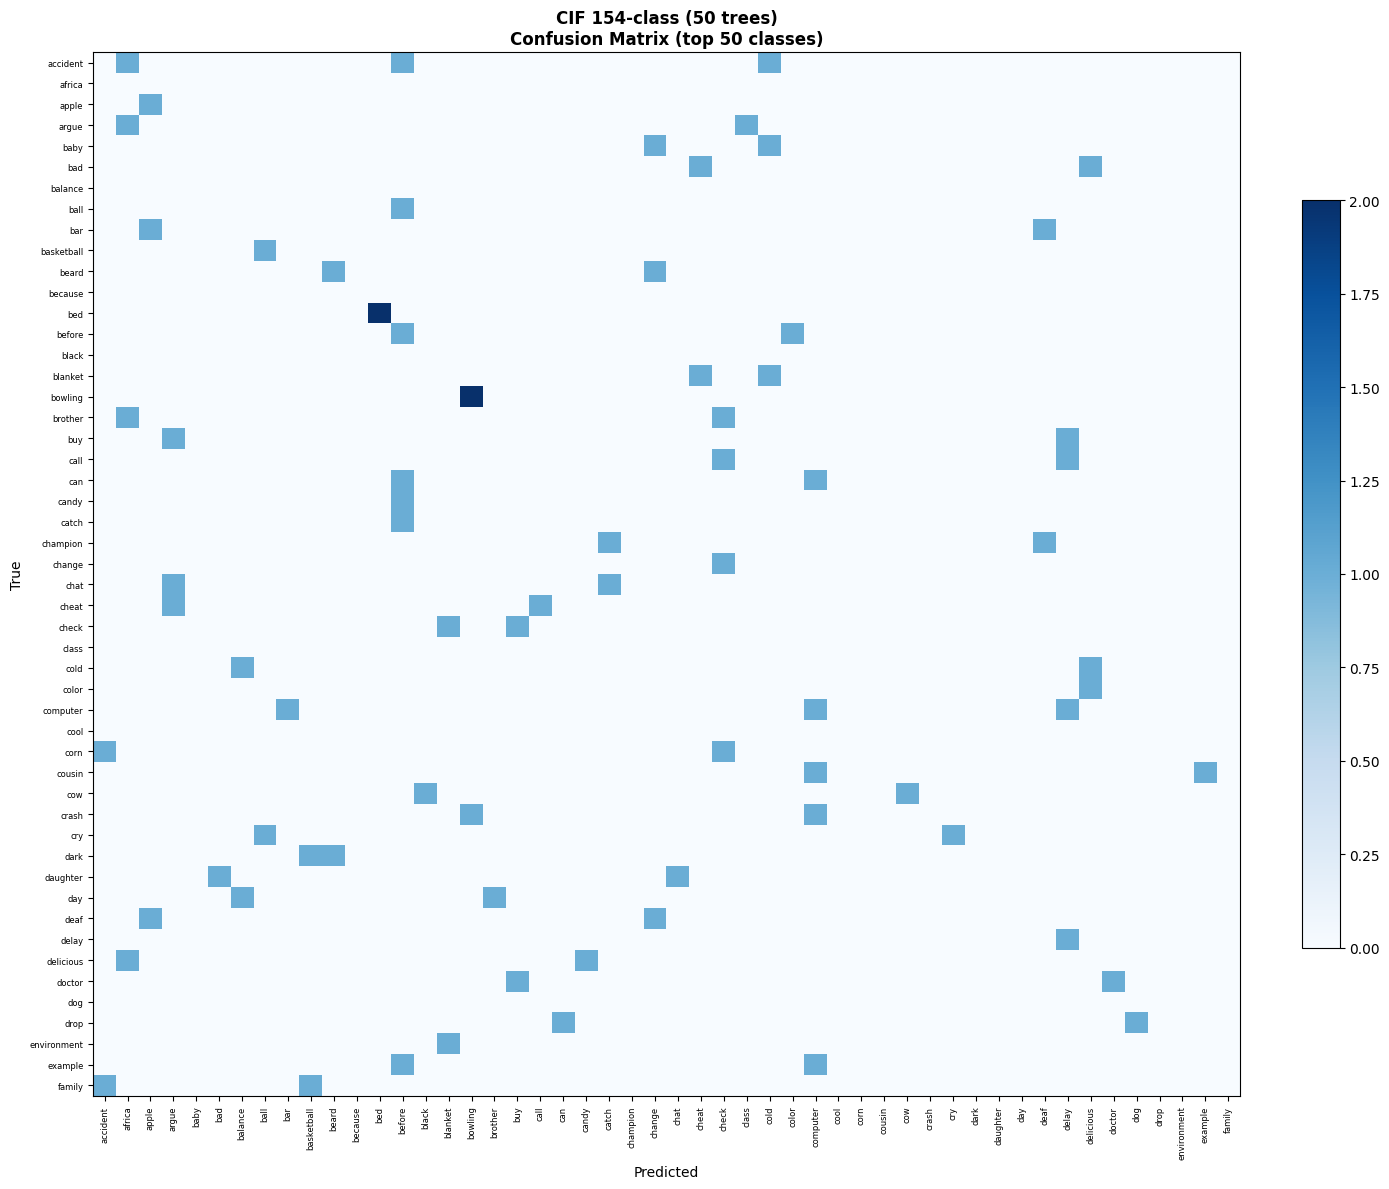

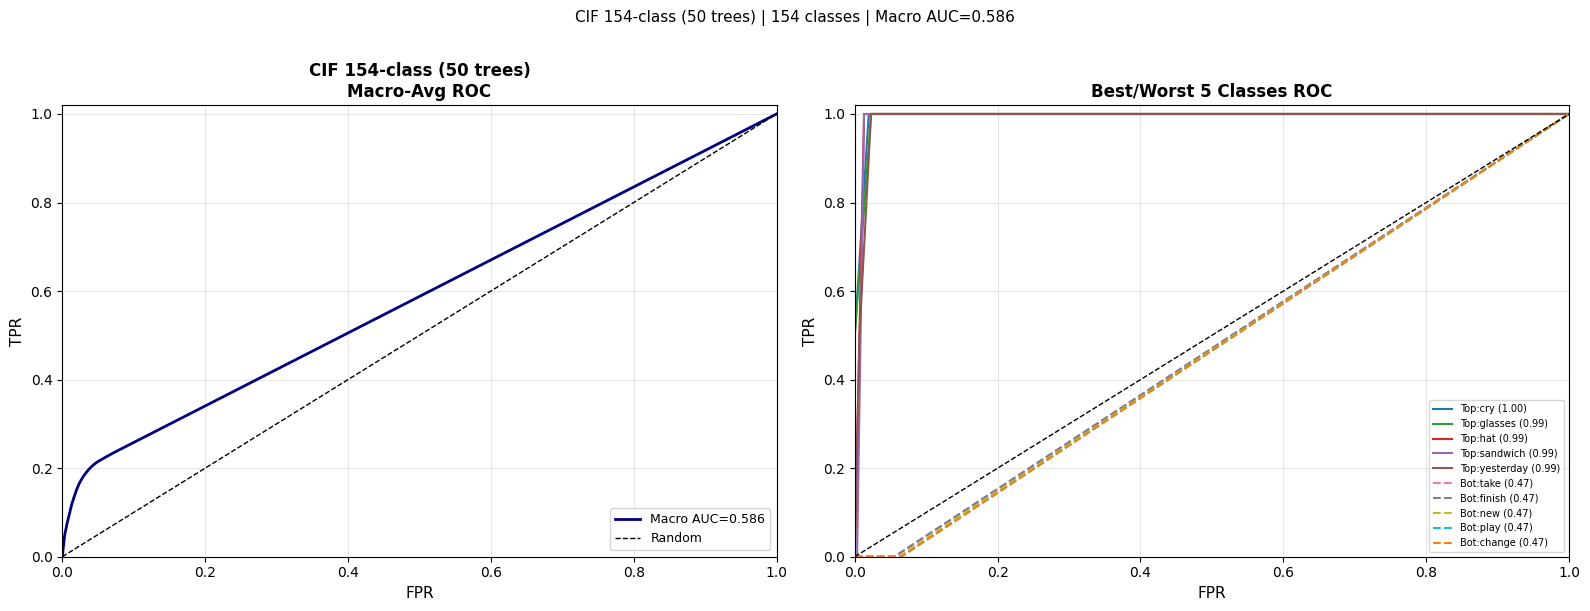

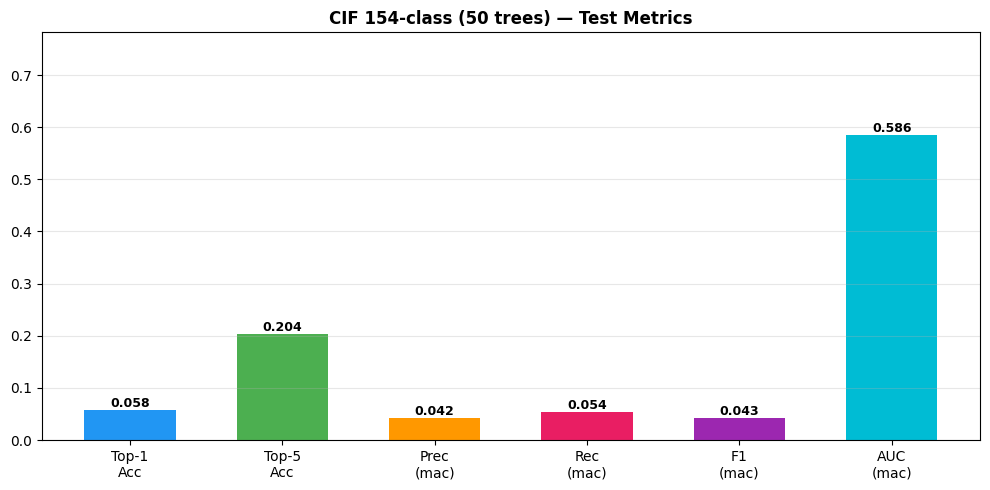


== CIF 154-class (50 trees) ==
  Top-1: 5.83%  Top-5: 20.39%
  Prec : 4.25%  Rec: 5.41%
  F1   : 4.31%  AUC: 0.5855

All outputs saved to: /content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/OBrown_DIS9300_v2/results/cif_154


In [8]:
print('Predicting on test set...')
y_proba = (clf.predict_proba(X_test) if hasattr(clf,'predict_proba')
           else np.eye(N_CLASSES)[clf.predict(X_test)])
print(f'y_proba shape: {y_proba.shape}')
np.save(os.path.join(RESULTS_DIR,'cif_154_proba_test.npy'), y_proba)

results = full_eval(y_test, y_proba, le, MODEL_NAME, MODEL_TAG, RESULTS_DIR)
print(f'\nAll outputs saved to: {RESULTS_DIR}')
